# 4. Baseline de referencia

**Objetivo:** medir el error de una referencia simple en las mismas particiones externas
que usarán los modelos. En cada fold se aprende la mediana exclusivamente con su entrenamiento
y se usa ese valor para los casos reservados. El MAE de esta referencia permite comprobar
si los descriptores geométricos aportan mejora predictiva.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src' / 'experimento.py').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Abra el notebook desde este repositorio.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.experimento import read_config, inspect_plan, load_model_data, find_completed_run, run_experiment
from src.particiones import nested_plan
from src.modelo_baseline import build_baseline, evaluate_regression
from dataclasses import asdict

config, config_hash = read_config(ROOT / 'config' / 'model_config.yml')
X, y, trace, groups, quality, data_path, report_path = load_model_data(config)
pd.set_option('display.float_format', lambda value: f'{value:.3f}')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('Datos:', data_path.relative_to(ROOT))
print('Objetivo:', y.name, '[N]')

Datos: data\processed\preliminary\model_table.csv
Objetivo: First_Failure_Load_N [N]


## 4.1 Ajuste y predicción fuera de muestra

In [2]:
plan = nested_plan(X, config['protocol'], groups)
predictions, metrics = [], []
for p in plan:
    train, test = p['train'], p['test']
    estimator = build_baseline().fit(np.zeros((len(train), 1)), y.iloc[train])
    pred = estimator.predict(np.zeros((len(test), 1)))
    frame = trace.iloc[test].copy()
    frame['fold'] = p['fold']
    frame['observed'] = y.iloc[test].to_numpy()
    frame['predicted'] = pred
    predictions.append(frame)
    metrics.append({'fold': p['fold'], 'mediana_train_N': float(np.median(y.iloc[train])),
                    **asdict(evaluate_regression(y.iloc[test], pred))})
baseline_oof = pd.concat(predictions, ignore_index=True)
display(pd.DataFrame(metrics))

,fold,mediana_train_N,mae,rmse,medae,r2
0,1,100.655,30.013,45.884,11.455,-0.042
1,2,107.150,34.042,43.709,20.700,-0.000
2,3,107.150,46.486,57.075,44.100,-0.006
3,4,91.800,114.318,114.602,116.940,-201.107
4,5,103.010,37.242,48.761,28.990,-0.009


## 4.2 Métricas agregadas y predicciones

,mae,rmse,medae,r2
baseline OOF,51.558,66.803,38.770,-0.293


,__source_record,Case_n,fold,observed,predicted
0,1,1,1,47.550,100.655
6,3,3,2,88.500,107.150
7,4,4,2,86.450,107.150
11,5,5,3,59.680,107.150
12,6,6,3,63.050,107.150
8,7,7,2,71.190,107.150
21,8,8,5,74.020,103.010
22,9,9,5,61.430,103.010
1,10,10,1,114.300,100.655
2,11,11,1,100.770,100.655


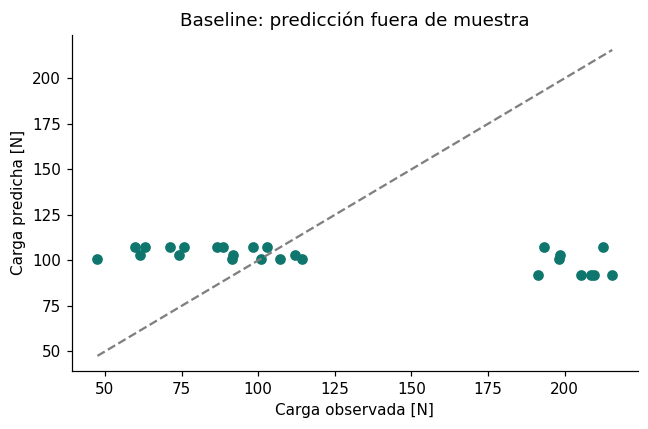

In [3]:
baseline_metrics = asdict(evaluate_regression(baseline_oof['observed'], baseline_oof['predicted']))
display(pd.DataFrame([baseline_metrics], index=['baseline OOF']))
display(baseline_oof.sort_values('Case_n', key=lambda s: pd.to_numeric(s)).head(10))
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(baseline_oof['observed'], baseline_oof['predicted'], color='#0f766e')
bounds = [min(baseline_oof[['observed', 'predicted']].min()), max(baseline_oof[['observed', 'predicted']].max())]
ax.plot(bounds, bounds, '--', color='gray')
ax.set(xlabel='Carga observada [N]', ylabel='Carga predicha [N]', title='Baseline: predicción fuera de muestra')
plt.tight_layout(); plt.show()

## 4.3 Interpretación

MAE, RMSE y MedAE se expresan en newtons. R² puede ser negativo: significa que, en esta
evaluación, el error cuadrático supera al de predecir la media observada del conjunto evaluado.
Los folds tienen medianas de entrenamiento distintas; no se emplea una mediana global.

Siguiente: [05 · Entrenamiento, ajuste y validación](05_Entrenamiento_Ajuste_y_Validacion.ipynb).